<a href="https://colab.research.google.com/github/Ronaldo-Junior1/analise-dados-atividade2/blob/main/RandomForestRegressor_SupportVectorRegressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Dicionário das variáveis**

* **Data** : Identifica a Sazonalidade daquela Temperatura
* **Hora** : Identifica a Hora que a Temperatura foi Registrada
* **Pressao** : Pressão no momento de registro da Temperatura
* **Radiacao** : Radiação no momento de registro da Temperatura
* **Temp_Inst** : Temperatura Registrada
* **Pto_Orvalho** : Ponto de Orvalho no momento de registro da Temperatura
* **Umid_Inst** : Umidade no momento de registro da Temperatura
* **Vento_Vel** : Velocidade do Vento no momento de registro da Temperatura

# Importando Pacotes Necessários

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [18]:
boston = fetch_openml(name="Boston", version=1, as_frame=True,parser='pandas' )
X = boston.data.astype(float)
y = boston.target.astype(float)

In [19]:
sns.set_theme(style="whitegrid", palette='rocket')
#sns.color_palette("flare", as_cmap=True)

In [20]:
#. Importando Base de Dados
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Analise_dados"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Configurando Base de Dados

In [21]:
column_names = [
    'data', 'hora', 'pressao', 'radiacao', 'temp_inst' , 'pto_orvalho_inst',
    'umid_inst', 'vento_vel'
]
df = pd.read_csv(f'{path}/A519.csv', sep=';', encoding='latin1')

In [22]:
print(df.columns)

Index(['data', 'hora', 'pressao', 'radiacao', 'temp_inst', 'pto_orvalho_inst',
       'umid_inst', 'vento_vel', 'Unnamed: 8'],
      dtype='object')


In [23]:
df = df.drop(columns='Unnamed: 8')

In [24]:
df.columns = column_names

# Análise Exploratória/Limpeza dos Dados

In [25]:
df.head(10)

,data,hora,pressao,radiacao,temp_inst,pto_orvalho_inst,umid_inst,vento_vel
0,2013-12-03,0,949.3,-3.540,22.3,21.0,92.0,2.3
1,2013-12-03,100,949.7,-3.540,22.1,20.6,91.0,2.1
2,2013-12-03,200,949.4,-3.540,22.1,20.0,88.0,1.3
3,2013-12-03,300,949.1,-3.540,21.9,20.2,90.0,2.3
4,2013-12-03,400,948.6,-3.540,21.4,19.8,91.0,1.5
5,2013-12-03,500,947.8,-3.540,21.2,19.8,92.0,2.0
6,2013-12-03,600,947.3,-3.540,20.8,19.4,92.0,1.8
7,2013-12-03,700,947.7,-3.540,20.4,19.6,95.0,1.7
8,2013-12-03,800,948.3,-3.445,20.4,19.7,95.0,1.8
9,2013-12-03,900,949.2,38.054,20.6,19.8,95.0,1.9


In [26]:
df.shape

(83232, 8)

- Podemos ver que nosso DataSet possui mais de 83 mil registros, o que é uma quantidade significativa de dados

In [27]:
df.describe()

,hora,pressao,radiacao,temp_inst,pto_orvalho_inst,umid_inst,vento_vel
count,83232.000000,77953.000000,77953.000000,77953.000000,77948.000000,77947.000000,77953.000000
mean,1150.000000,950.645189,854.659699,24.266163,15.971423,64.328492,1.797509
std,692.222814,3.183373,1127.039563,5.117659,4.969063,21.084565,1.377348
min,0.000000,938.900000,-3.540000,2.000000,-10.000000,8.000000,0.000000
25%,575.000000,948.500000,-3.529000,21.000000,12.500000,49.000000,0.800000
50%,1150.000000,950.500000,79.662000,23.600000,17.300000,67.000000,1.500000
75%,1725.000000,952.700000,1727.162000,28.100000,19.800000,82.000000,2.500000
max,2300.000000,963.000000,4291.431000,40.900000,33.200000,100.000000,10.300000


- Podemos ver que nosso DataSet possui outliers. Já que, 75% dos dados estão abaixo de 28°C. Mas, o máximo registrado é de aproximadamente 40°C, sendo um valor muito alto em comparação com os demais valores registrados.

In [28]:
df.dtypes

,0
data,object
hora,int64
pressao,float64
radiacao,float64
temp_inst,float64
pto_orvalho_inst,float64
umid_inst,float64
vento_vel,float64


- Aqui podemos ver que a variável Data está no formato errado. Será preciso corrigir isso futuramente

In [29]:
((df.isnull().sum() / df.shape[0])*100).sort_values(ascending=False)

,0
umid_inst,6.349721
pto_orvalho_inst,6.348520
radiacao,6.342512
pressao,6.342512
temp_inst,6.342512
vento_vel,6.342512
data,0.000000
hora,0.000000


- Podemos ver que nosso DataSet possui dados nulos.

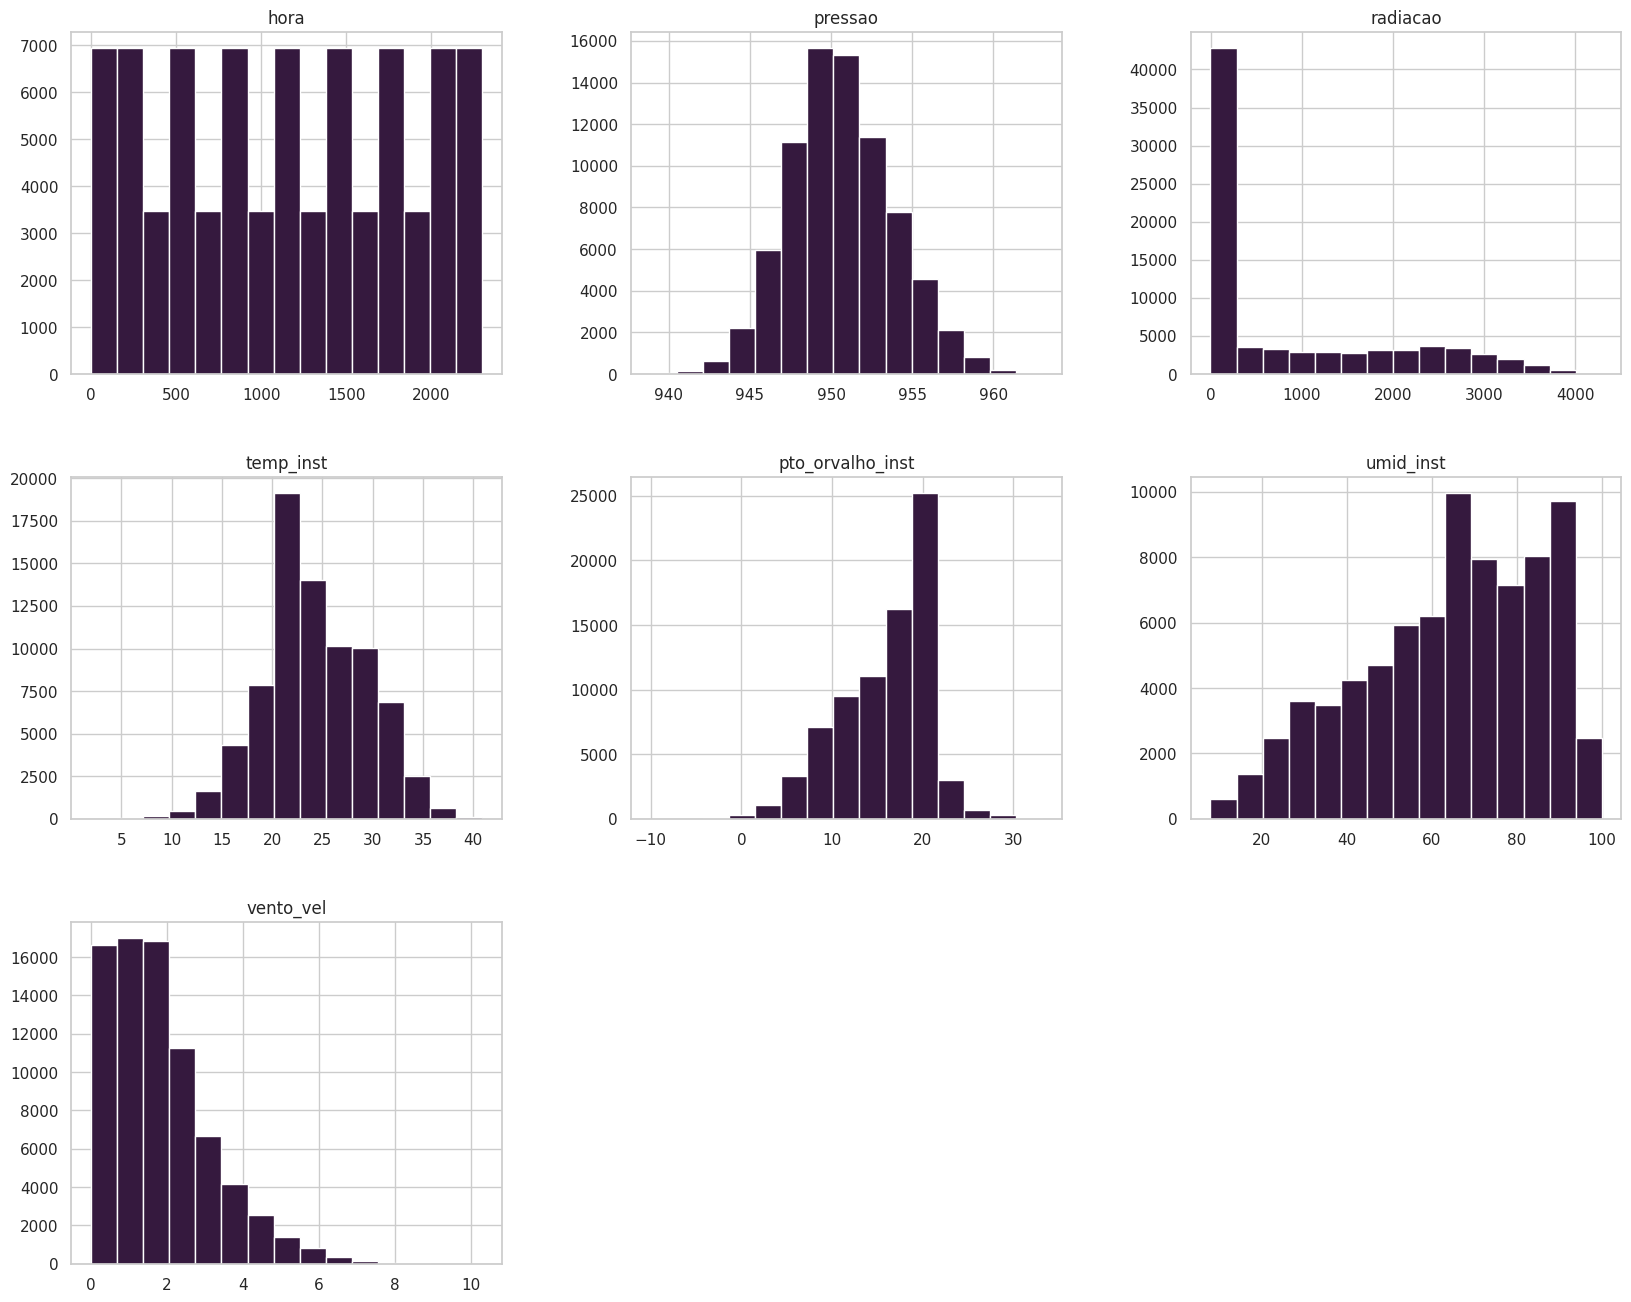

In [30]:
df.hist(bins=15, figsize=(20,16));

- Podemos ver que as variáveis temperatura e pressão possuim uma distribuição próxima de uma distribuição normal. Já as outras variáveis, não apresentam uma distribuição normal.

- Após uma breve análise dos dados, será necessário fazer algumas alterações/modificações para que se obtenha uma maior eficiência dos algoritmos

In [31]:
#. Transformando a coluna Data para seu tipo correto:
df['data'] = pd.to_datetime(df['data'])

#. Removendo valores Nulos
df.dropna(inplace=True)

#. Criando uma nova coluna para armazenar as horas convertidas, para uma melhor manipulação da variável
df['hora_int'] = df['hora'] // 100

#. criando uma nova coluna para armazenar os valores corrigidos da radiação (Sem valores negativos)
df['radiacao_clip'] = df['radiacao'].clip(lower=0)

#. Transformando Hora em SEN e COS para que a continuidade circular (24h) seja preservada
df['hora_sin'] = np.sin(2 * np.pi * df['hora_int'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora_int'] / 24)

#. Plicando a mesma regra de SEN e COS para manter a continuidade anual (12 meses)
df['mes'] = df['data'].dt.month
df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)

- Agora vamos preparar nosso DataSet para o treinamento dos Algoritmos

In [32]:
#. Separando as variáveis que serão utilizadas
features = [
    'pressao',          # Pressão atmosférica
    'radiacao_clip',    # Radiação solar (clipada em 0)
    'pto_orvalho_inst', # Ponto de orvalho
    'umid_inst',        # Umidade relativa
    'vento_vel',        # Velocidade do vento
    'hora_sin',         # Componente seno do ciclo diário
    'hora_cos',         # Componente cosseno do ciclo diário
    'mes_sin',          # Componente seno do ciclo anual
    'mes_cos'           # Componente cosseno do ciclo anual
]

#. Definindo a variável a qual queremos prever
target = 'temp_inst'

X = df[features]
y = df[target]
print(f'\nX: {X.shape} | y: {y.shape}')


X: (77945, 9) | y: (77945,)
